In [1]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
from jax import grad, vmap
import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import summary as diagnostic_summary
from numpyro.infer import MCMC, NUTS, init_to_value

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 140

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The printed text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Bayesian PINNs for Inverse Problems


In the previous notebook we trained a deterministic inverse PINN and recovered a single best-fit value of the unknown conductivity. The remaining inverse-problem question is the uncertainty in that conductivity and in the reconstructed state.

Bayesian physics-informed neural networks (B-PINNs) address this question by defining a posterior distribution over the unknown quantities rather than returning only one optimizer output. The general framework was introduced by {cite:t}`yang2021bpinns`, building directly on the PINN formulation of {cite:t}`raissi2019physics`.

Bayesian inference for a large neural network can be expensive, so this notebook uses a deliberately small example. We keep the same one-dimensional diffusion inverse problem and infer the 25 network parameters together with the unknown conductivity. The resulting posterior is conditional on this finite network, the selected collocation points, and the noise scales specified below.



## Problem setup

We again study

$$
\begin{aligned}
-\theta u''(x) &= \sin(\pi x), \quad x \in (0,1),\\
u(0) &= 0,\\
u(1) &= 0,
\end{aligned}
$$

with unknown conductivity $\theta > 0$.

The exact solution is still

$$
u^\star(x;\theta) = \frac{\sin(\pi x)}{\theta \pi^2},
$$

and we use it only to manufacture noisy observations. The difference from the previous notebook is not the PDE. It is the inference target. Instead of searching for a single minimizer of the PINN loss, we will sample from a posterior distribution over the neural-network parameters and $\theta$.

In B-PINNs the PDE residual is treated as another source of information. We introduce a Gaussian pseudo-likelihood for the residual values at 15 collocation points. This is a finite approximation to enforcing the continuum PDE, and its scale represents a chosen tolerance for residual mismatch rather than measured process noise.

In [3]:
true_theta = 0.7
noise_std = 3e-3
width = 8
n_obs = 9

def source_term(x):
    return jnp.sin(jnp.pi * x)

def exact_solution(x, theta=true_theta):
    return jnp.sin(jnp.pi * x) / (theta * jnp.pi**2)

key = jr.PRNGKey(11)
key, noise_key = jr.split(key)

x_obs = jnp.linspace(0.1, 0.9, n_obs)
y_clean = exact_solution(x_obs)
y_obs = y_clean + noise_std * jr.normal(noise_key, x_obs.shape)
x_phys = jnp.linspace(0.0, 1.0, 17)[1:-1]
xs_plot = jnp.linspace(0.0, 1.0, 200)

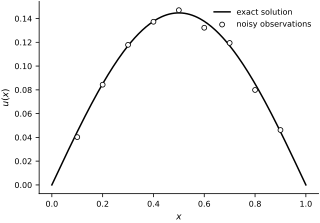

In [4]:
fig, ax = new_figure("full_standard")
ax.plot(
    xs_plot, exact_solution(xs_plot), color="black", linestyle="-",
    linewidth=1.5, label="exact solution"
)
ax.scatter(
    x_obs, y_obs, s=24, facecolors="white", edgecolors="black",
    linewidths=0.8, zorder=3, label="noisy observations"
)
ax.set(xlabel=r"$x$", ylabel=r"$u(x)$")
ax.legend(loc="upper right")
finalize_axes(ax)
plt.show()

## A small PINN parameterization

To keep Hamiltonian Monte Carlo affordable, we use a tiny one-hidden-layer network with eight hidden units. As before, the boundary conditions are enforced by construction:

$$
u_\mathbf{w}(x) = x(1-x)\,\text{NN}_\mathbf{w}(x).
$$

The conductivity is written as $\theta = e^{\eta}$ so positivity is automatic. In this notebook the unknowns are the weight vector $\mathbf{w}$ and the transformed conductivity parameter $\eta$.

In [5]:
n_nn_params = 3 * width + 1

def unpack(nn_params):
    w1 = nn_params[:width]
    b1 = nn_params[width:2 * width]
    w2 = nn_params[2 * width:3 * width]
    b2 = nn_params[-1]
    return w1, b1, w2, b2

def pinn_solution(x, nn_params):
    w1, b1, w2, b2 = unpack(nn_params)
    hidden = jnp.tanh(w1 * x + b1)
    out = jnp.dot(w2, hidden) + b2
    return x * (1.0 - x) * out

def pinn_residual(x, nn_params, theta):
    u_x = grad(lambda z: pinn_solution(z, nn_params))
    u_xx = grad(u_x)
    return -theta * u_xx(x) - source_term(x)

total_dim = n_nn_params + 1
print(f"Bayesian parameter dimension: {total_dim}")

Bayesian parameter dimension: 26


## Deterministic initialization

Sampling works better when we initialize near a sensible part of parameter space. We therefore minimize the weighted deterministic PINN objective from the previous notebook and use the result to initialize NUTS. Its weights do not match the prior and likelihood scales in the Bayesian model below, so this point is not a maximum a posteriori estimate.

The fitted curve also provides a deterministic reference for the posterior summaries.

In [6]:
def deterministic_loss(params, x_obs, y_obs, x_phys, lambda_data=50.0, lambda_pde=1.0):
    nn_params = params[:-1]
    log_theta = params[-1]
    theta = jnp.exp(log_theta)
    pred_obs = vmap(lambda x: pinn_solution(x, nn_params))(x_obs)
    residual_values = vmap(lambda x: pinn_residual(x, nn_params, theta))(x_phys)
    data_loss = jnp.mean((pred_obs - y_obs) ** 2)
    pde_loss = jnp.mean(residual_values ** 2)
    prior_penalty = 1e-4 * jnp.mean(params ** 2)
    return lambda_data * data_loss + lambda_pde * pde_loss + prior_penalty

key, init_key = jr.split(key)
deterministic_params = jnp.concatenate([
    0.1 * jr.normal(init_key, (n_nn_params,)),
    jnp.array([jnp.log(1.5)]),
])

optimizer = optax.adam(1e-2)
opt_state = optimizer.init(deterministic_params)

@jax.jit
def deterministic_step(params, opt_state):
    loss_value, grads = jax.value_and_grad(deterministic_loss)(params, x_obs, y_obs, x_phys)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

deterministic_history = []
for step in range(3000):
    deterministic_params, opt_state, loss_value = deterministic_step(deterministic_params, opt_state)
    deterministic_history.append(float(loss_value))
    if step % 500 == 0 or step == 2999:
        print(f"step={step:4d} loss={float(loss_value):.6f} theta={float(jnp.exp(deterministic_params[-1])):.4f}")

step=   0 loss=1.982110 theta=1.4851
step= 500 loss=0.001315 theta=0.7054
step=1000 loss=0.000655 theta=0.7052
step=1500 loss=0.000632 theta=0.7052
step=2000 loss=0.000608 theta=0.7052
step=2500 loss=0.000586 theta=0.7052
step=2999 loss=0.000565 theta=0.7052


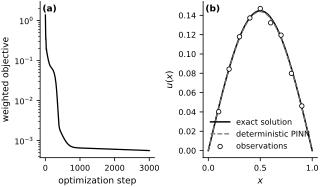

In [7]:
deterministic_theta = float(jnp.exp(deterministic_params[-1]))
deterministic_pred = vmap(
    lambda x: pinn_solution(x, deterministic_params[:-1])
)(xs_plot)

fig, axes = new_figure("full_landscape", ncols=2)
axes[0].semilogy(
    deterministic_history, color="black", linestyle="-", linewidth=1.3
)
axes[0].set(xlabel="optimization step", ylabel="weighted objective")

axes[1].plot(
    xs_plot, exact_solution(xs_plot), color="black", linestyle="-",
    linewidth=1.5, label="exact solution"
)
axes[1].plot(
    xs_plot, deterministic_pred, color="0.45", linestyle="--",
    linewidth=1.3, label="deterministic PINN"
)
axes[1].scatter(
    x_obs, y_obs, s=20, facecolors="white", edgecolors="black",
    linewidths=0.8, zorder=3, label="observations"
)
axes[1].set(xlabel=r"$x$", ylabel=r"$u(x)$")
axes[1].legend(loc="lower center", handlelength=2.4)
label_panels(axes)
finalize_axes(axes)
plt.show()

## Bayesian PINN model

Let $\mathbf{w}=(w_1,\ldots,w_{25})$ collect the network parameters and let $\eta=\log\theta$. We assign the independent priors

$$
w_k \overset{\mathrm{iid}}{\sim} \mathcal{N}(0,1),\qquad
\eta \sim \mathcal{N}(0,0.5^2),\qquad
\theta=e^\eta.
$$

The last transformation gives a lognormal prior for the positive conductivity. At the $N_d=9$ sensor locations, the observation model is

$$
y_i \mid \mathbf{w} \sim \mathcal{N}(u_\mathbf{w}(x_i), \sigma_\mathrm{data}^2),\qquad \sigma_\mathrm{data}=0.003.
$$

Define the residual

$$
r_\mathbf{w}(x;\theta)=-\theta u_\mathbf{w}''(x)-\sin(\pi x).
$$

At the $N_r=15$ collocation points, we use the pseudo-observation model

$$
0 \mid \mathbf{w}, \theta \sim \mathcal{N}(r_\mathbf{w}(x_j;\theta), \sigma_\mathrm{PDE}^2),\qquad \sigma_\mathrm{PDE}=0.02.
$$

Assuming conditional independence across sensors and collocation points, these factors and the priors define $p(\mathbf{w},\eta\mid\mathbf{y},\mathbf{r}=\mathbf{0})$. The residual factor supplies the physics information. Its scale $\sigma_\mathrm{PDE}$ is a modeling tolerance: changing it, or changing the number and locations of collocation points, changes the posterior.

In [8]:
sigma_pde = 0.02

def bpinn_model(x_obs, y_obs, x_phys):
    nn_params = numpyro.sample("nn_params", dist.Normal(0.0, 1.0).expand([n_nn_params]))
    log_theta = numpyro.sample("log_theta", dist.Normal(jnp.log(1.0), 0.5))
    theta = jnp.exp(log_theta)

    pred_obs = vmap(lambda x: pinn_solution(x, nn_params))(x_obs)
    pred_res = vmap(lambda x: pinn_residual(x, nn_params, theta))(x_phys)

    numpyro.sample("y", dist.Normal(pred_obs, noise_std).to_event(1), obs=y_obs)
    numpyro.sample("r", dist.Normal(pred_res, sigma_pde).to_event(1), obs=jnp.zeros_like(x_phys))

## Posterior sampling and diagnostics

We run four sequential NUTS chains, using 1,000 warmup iterations and retaining 1,000 draws from each chain. Each transition differentiates through the network and its second spatial derivative at all collocation points, so this approach becomes expensive as the network and collocation set grow.

Neural-network parameterizations have symmetries, so individual weight coordinates can mix slowly even when the inferred conductivity and state are stable. We therefore report split-$\widehat{R}$ and effective sample size for $\theta$ and for the representative state value $u(0.5)$, together with the number of divergent transitions. These diagnostics can reveal sampling problems; they do not prove convergence.

In [9]:
init_values = {
    "nn_params": deterministic_params[:-1],
    "log_theta": deterministic_params[-1],
}

nuts = NUTS(
    bpinn_model,
    init_strategy=init_to_value(values=init_values),
    target_accept_prob=0.9,
)
mcmc = MCMC(
    nuts, num_warmup=1000, num_samples=1000, num_chains=4,
    chain_method="sequential", progress_bar=False,
)

key, mcmc_key = jr.split(key)
mcmc.run(mcmc_key, x_obs=x_obs, y_obs=y_obs, x_phys=x_phys)
posterior_by_chain = mcmc.get_samples(group_by_chain=True)
posterior = mcmc.get_samples()
divergences = int(mcmc.get_extra_fields()["diverging"].sum())

theta_by_chain = jnp.exp(posterior_by_chain["log_theta"])
theta_samples = jnp.exp(posterior["log_theta"])
u_mid_by_chain = vmap(
    vmap(lambda nn_params: pinn_solution(0.5, nn_params))
)(posterior_by_chain["nn_params"])
diagnostics = diagnostic_summary(
    {"theta": theta_by_chain, "u_mid": u_mid_by_chain}, group_by_chain=True
)
theta_diagnostics = diagnostics["theta"]
midpoint_diagnostics = diagnostics["u_mid"]

print("Chains: 4; warmup: 1,000 per chain; retained: 1,000 per chain")
print(f"Posterior mean conductivity: {theta_samples.mean():.4f}")
print(f"Posterior std conductivity:  {theta_samples.std():.4f}")
print(f"90% credible interval:       [{jnp.quantile(theta_samples, 0.05):.4f}, {jnp.quantile(theta_samples, 0.95):.4f}]")
print(f"theta R-hat / ESS:           {float(theta_diagnostics['r_hat']):.3f} / {float(theta_diagnostics['n_eff']):.0f}")
print(f"u(0.5) R-hat / ESS:          {float(midpoint_diagnostics['r_hat']):.3f} / {float(midpoint_diagnostics['n_eff']):.0f}")
print(f"Divergences:                 {divergences}")

Chains: 4; warmup: 1,000 per chain; retained: 1,000 per chain
Posterior mean conductivity: 0.7047
Posterior std conductivity:  0.0078
90% credible interval:       [0.6920, 0.7177]
theta R-hat / ESS:           1.008 / 250
u(0.5) R-hat / ESS:          1.004 / 405
Divergences:                 0


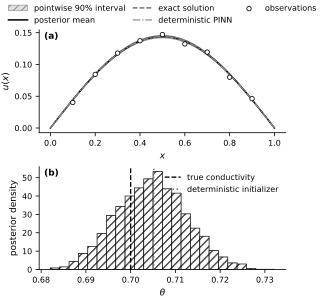

In [10]:
posterior_curves = vmap(
    lambda nn_params: vmap(lambda x: pinn_solution(x, nn_params))(xs_plot)
)(posterior["nn_params"])
curve_mean = posterior_curves.mean(axis=0)
curve_q05 = jnp.quantile(posterior_curves, 0.05, axis=0)
curve_q95 = jnp.quantile(posterior_curves, 0.95, axis=0)

theta_deterministic = jnp.exp(deterministic_params[-1])

fig, axes = new_figure("full_tall", nrows=2)

axes[0].fill_between(
    xs_plot, curve_q05, curve_q95, facecolor="0.88", edgecolor="0.55",
    linewidth=0.6, hatch="///", label="pointwise 90% interval"
)
axes[0].plot(
    xs_plot, curve_mean, color="black", linestyle="-",
    linewidth=1.5, label="posterior mean"
)
axes[0].plot(
    xs_plot, exact_solution(xs_plot), color="0.35", linestyle="--",
    linewidth=1.3, label="exact solution"
)
axes[0].plot(
    xs_plot, deterministic_pred, color="0.55", linestyle="-.",
    linewidth=1.2, label="deterministic PINN"
)
axes[0].scatter(
    x_obs, y_obs, s=20, facecolors="white", edgecolors="black",
    linewidths=0.8, zorder=3, label="observations"
)
axes[0].set(xlabel=r"$x$", ylabel=r"$u(x)$")
axes[0].legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3,
    borderaxespad=0.0, columnspacing=0.9, handlelength=2.4,
)

axes[1].hist(
    theta_samples, bins=24, density=True, facecolor="white",
    edgecolor="black", linewidth=0.7, hatch="///"
)
axes[1].axvline(
    true_theta, color="black", linestyle="--", linewidth=1.3,
    label="true conductivity"
)
axes[1].axvline(
    theta_deterministic, color="0.45", linestyle=":", linewidth=1.5,
    label="deterministic initializer"
)
axes[1].set(xlabel=r"$\theta$", ylabel="posterior density")
axes[1].legend(loc="upper right")
label_panels(axes)
finalize_axes(axes)
plt.show()

In [11]:
posterior_mean_curve = curve_mean
rel_l2_deterministic = (
    jnp.linalg.norm(deterministic_pred - exact_solution(xs_plot))
    / jnp.linalg.norm(exact_solution(xs_plot))
)
rel_l2_bayes = jnp.linalg.norm(posterior_mean_curve - exact_solution(xs_plot)) / jnp.linalg.norm(exact_solution(xs_plot))

print(f"Deterministic conductivity:  {float(theta_deterministic):.4f}")
print(f"Posterior mean conductivity: {float(theta_samples.mean()):.4f}")
print(f"Deterministic relative L2:   {float(rel_l2_deterministic):.4f}")
print(f"Posterior mean L2 error:     {float(rel_l2_bayes):.4f}")

Deterministic conductivity:  0.7052
Posterior mean conductivity: 0.7047
Deterministic relative L2:   0.0073
Posterior mean L2 error:     0.0070


The deterministic and posterior-mean answers are close because this manufactured inverse problem is well identified. For $\theta>0$, the exact state $u^\star(x;\theta)=\sin(\pi x)/(\theta\pi^2)$ is injective in $\theta$ at every interior point where $\sin(\pi x)\ne0$. With noisy data, the posterior is concentrated in this run, conditional on the selected priors and residual pseudo-likelihood.

The four-chain diagnostics above assess the identifiable conductivity and the representative state value $u(0.5)$. Values of $\widehat{R}$ near one, adequate effective sample sizes, and no divergent transitions provide evidence against obvious sampling failure for these summaries, but they do not establish that every neural-network weight coordinate has mixed.

The retained draws approximate the posterior distribution. The shaded region is the pointwise interval between the 5th and 95th percentiles of the latent state $u_\mathbf{w}(x)$; it is neither a simultaneous band nor a posterior-predictive interval for a new noisy observation. Its width is conditional on the network architecture, the fixed observation-noise scale, and the 15 collocation points. The residual scale `sigma_pde` is a modeling tolerance: decreasing it enforces smaller residuals, while treating more collocation residuals as independent observations can also make the posterior more concentrated.

## Exercises

Restart the kernel and run all cells for each experiment. Report the posterior mean and 90% credible interval for $\theta$, the $\widehat{R}$ and effective sample size values, the number of divergences, and the relative $L^2$ state error.

1. Create a fixed dense set of candidate sensor locations and one fixed noise realization. Compare nested subsets of these observations. How does the credible interval for $\theta$ change as information is added?
2. Increase `noise_std` and regenerate the observations with the same random key. Compare the latent-state interval with a posterior-predictive interval that also includes new measurement noise. What happens at the two boundaries?
3. Decrease `sigma_pde` from `0.02` to `0.01`. How do the posterior summaries and sampling diagnostics change? Explain why this changes the statistical model rather than only the numerical accuracy.
4. Replace the hidden layer with a wider one. Compare the state and conductivity summaries, and check whether the additional weight symmetries degrade the diagnostics.
5. Reduce the number of observations or increase their noise until the deterministic fit remains plausible but the conductivity posterior is broad. Explain what the point estimate alone conceals.